#Insight de Negócios 4

##Atenção importante##
A coluna release_year NÃO representa quando o conteúdo entrou na Netflix.
Ela representa o ano de lançamento original do filme ou série.

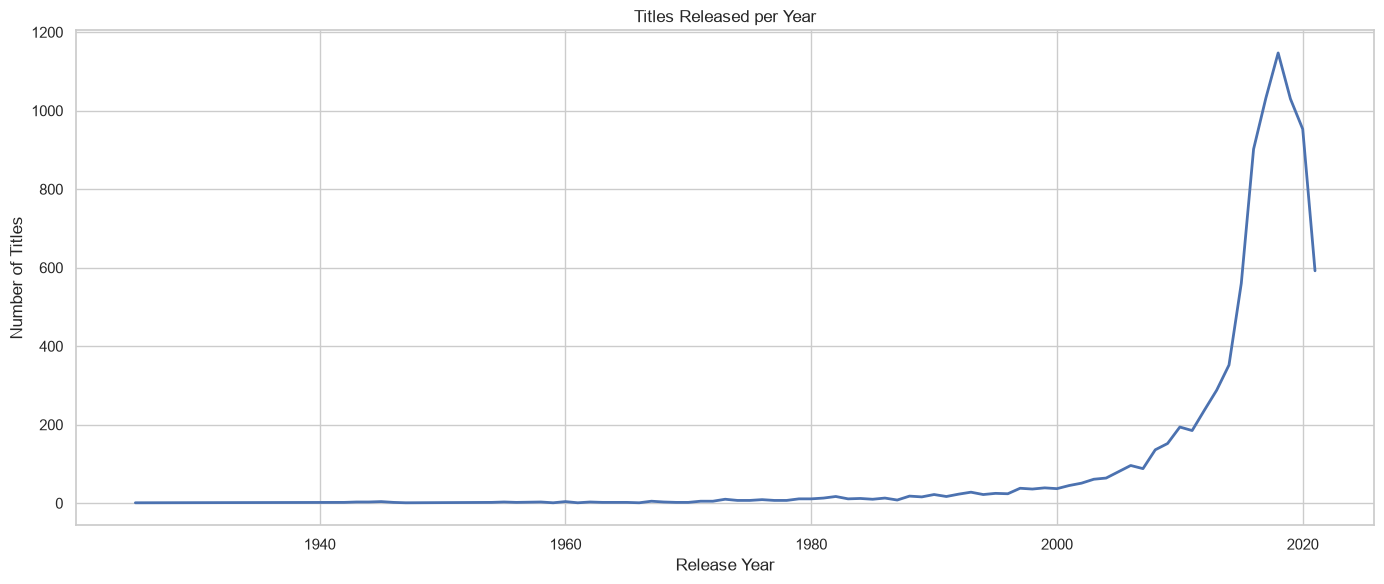

In [15]:
#Questão de Negócios 4 - Código 
titles_per_year = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

titles_per_year.head()

#Graphico
plt.figure(figsize=(14, 6))

sns.lineplot(
    x=titles_per_year.index,
    y=titles_per_year.values,
    linewidth=2
)

plt.title("Titles Released per Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig(
    "../images/titles_per_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão de Negócio 4
Como evoluiu a produção ao longo dos anos?

#Hipótese
O número de títulos cresceu significativamente a partir de 2015.

##Insight de Negócio 3

Os gêneros Drama e International Movies aparecem com maior frequência.

Isso sugere que a Netflix prioriza conteúdos de ampla aceitação internacional.

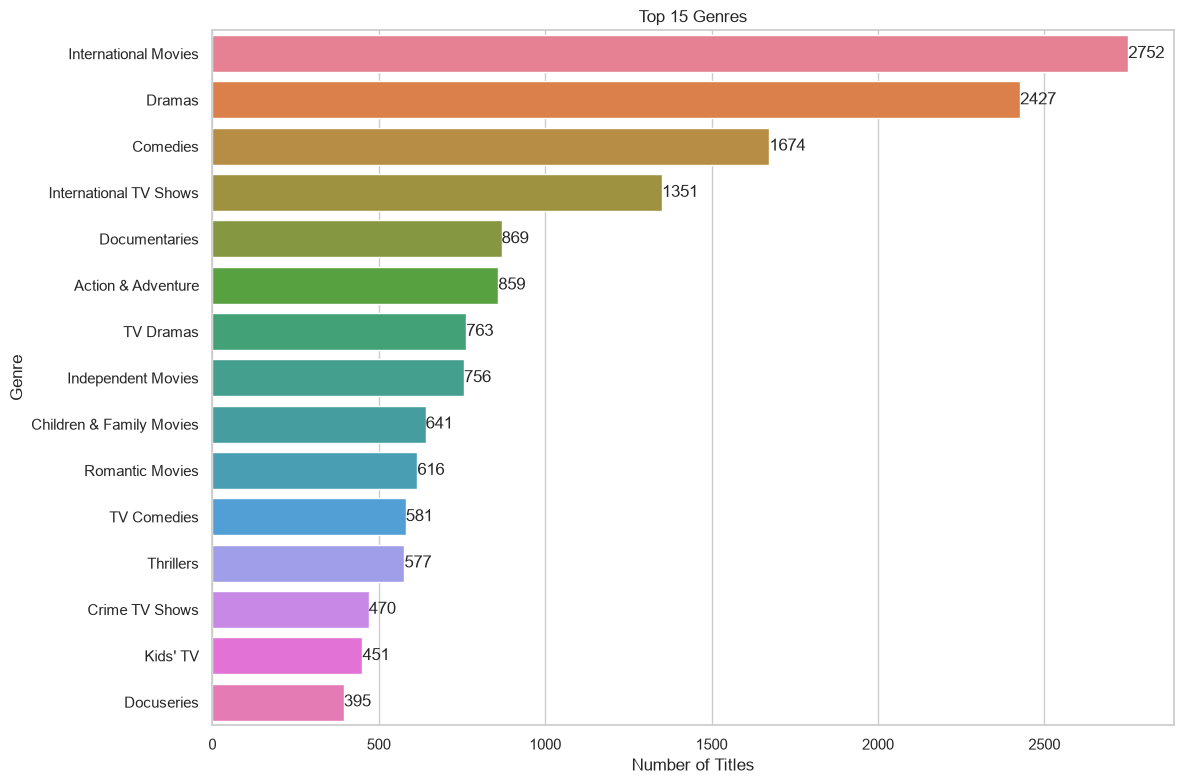

In [14]:
#Questão de Negócio 3 - Código
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = (
    genres
    .value_counts()
    .head(15)
)

top_genres

#Graphico

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    legend=False
)

plt.title("Top 15 Genres")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão de Negócio 3

Quais são os gêneros mais frequentes?

#Hipótese
Dramas e Comédias serão predominantes.

##Insight de Negócio - Pergunta 2

Os Estados Unidos concentram a maior parte das produções disponíveis no catálogo.

Isso indica forte dependência do mercado norte-americano para composição do catálogo.

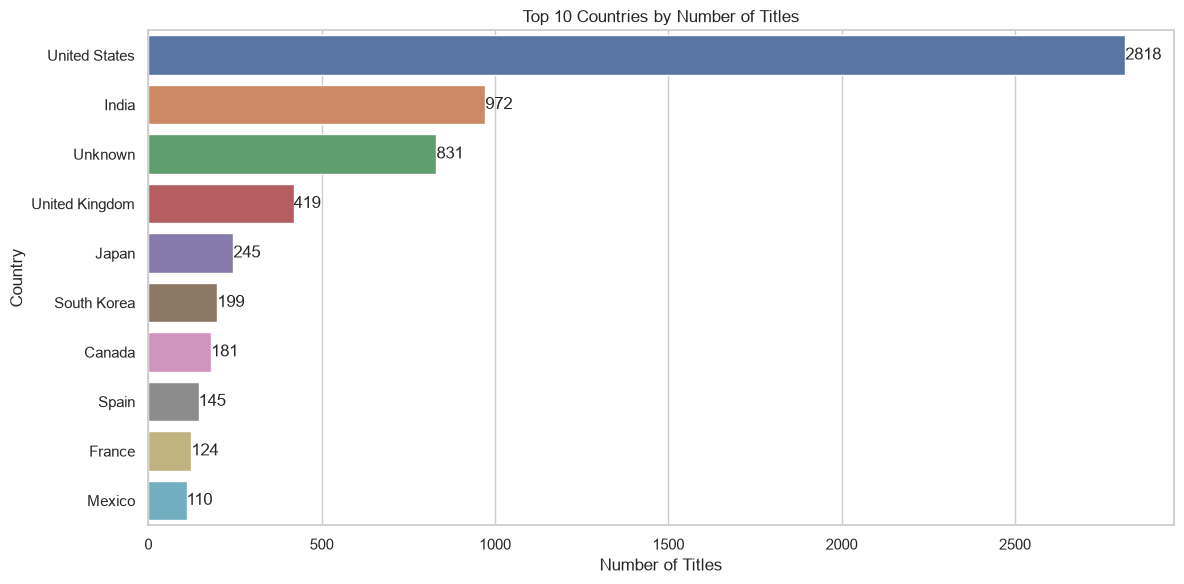

In [13]:
#Questão de Negócio 2 - Código

top_countries = (
    df["country"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

top_countries

#Graphico

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    legend=False
)

plt.title("Top 10 Countries by Number of Titles")

plt.xlabel("Number of Titles")

plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão de Negócio 2

Quais países produzem mais conteúdo?

- principais mercados;
- concentração da produção;
- oportunidades de expansão.

#Hipótese
Os Estados Unidos lideram a produção.

#Insight de negócio - Pergunta 1

A Netflix concentra seu catálogo em filmes.

#Essa informação pode indicar:
- menor custo de licenciamento;
- maior disponibilidade de filmes;
- estratégia de oferecer maior variedade de conteúdo de curta duração.

Isso demonstra que a estratégia histórica da Netflix foi ampliar rapidamente a quantidade de títulos disponíveis, utilizando principalmente filmes.

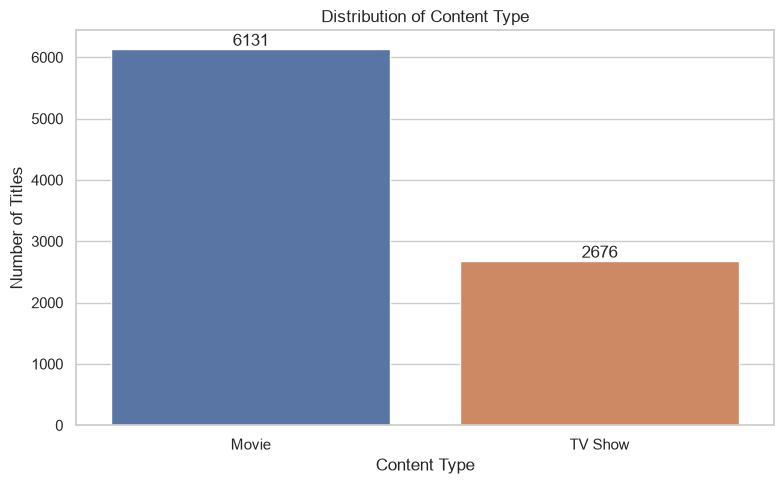

In [12]:
##Questão de Negócio 1 - Código

#Count
content_type = (
    df["type"]
    .value_counts()
)

content_type

#Percentage
content_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

content_percentage

#Graphicos
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="type",
    hue="type",
    legend=False
)

plt.title("Distribution of Content Type")

plt.xlabel("Content Type")

plt.ylabel("Number of Titles")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/content_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Questão de Negócio 1

O catálogo possui mais filmes ou séries?

- Antes de qualquer análise detalhada, precisamos entender a composição do catálogo.

#Essa informação pode indicar:
- foco estratégico da plataforma;
- comportamento histórico da empresa;
- perfil do conteúdo disponível.

#Hipótese
A Netflix possui mais filmes do que séries.

In [11]:
##Importar dataset
DATASET_PATH = "../data/processed/netflix_clean.csv"

df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["date_added"]
)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,weekday_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.00,September,Saturday
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.00,September,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.00,September,Friday
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.00,September,Friday
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.00,September,Friday


In [10]:
##Preparar ambiente

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

##Capítulo 4 — Exploratory Data Analysis (EDA)

##Objetivos
Responder perguntas de negócio utilizando análise exploratória.

##Cada análise seguirá o fluxo:
Pergunta > Hipótese > Código > Visualização > Interpretação > Insight > Impacto para o negócio